# # STRING DB Multi-Level Pathway Analysis
# 
# Multi-level protein interaction network analysis starting from a seed protein

# ## Step 1: Install and Import Required Packages

In [1]:
# Check and install required packages for conda environment
import subprocess
import sys
import os

def install_package_conda(package):
    try:
        __import__(package)
        print(f"✓ {package} already available")
        return True
    except ImportError:
        print(f"Installing {package}...")
        try:
            # Try conda first
            subprocess.check_call(["conda", "install", "-y", package])
            print(f"✓ {package} installed via conda")
            return True
        except:
            try:
                # Fallback to pip
                subprocess.check_call([sys.executable, "-m", "pip", "install", package])
                print(f"✓ {package} installed via pip")
                return True
            except Exception as e:
                print(f"✗ Failed to install {package}: {e}")
                return False

# Check current environment
print(f"Python executable: {sys.executable}")
print(f"Current working directory: {os.getcwd()}")

# Install required packages
required_packages = ['requests', 'pandas', 'networkx', 'matplotlib', 'numpy']
success = True
for package in required_packages:
    if not install_package_conda(package):
        success = False

if not success:
    print("\n⚠️  Some packages failed to install. Please run manually:")
    print("conda install requests pandas networkx matplotlib numpy")
    print("or")
    print("pip install requests pandas networkx matplotlib numpy")

Python executable: /Users/robinsonvidva/miniconda/envs/pathway_analysis/bin/python
Current working directory: /Users/robinsonvidva/Github/robinson-vidva/pathway_analysis
✓ requests already available
✓ pandas already available
✓ networkx already available
✓ matplotlib already available
✓ numpy already available


In [2]:
# Import libraries with error handling
import sys
print("Attempting to import packages...")

try:
    import requests
    print("✓ requests imported")
except ImportError as e:
    print(f"✗ requests failed: {e}")
    sys.exit("Please install requests: conda install requests")

try:
    import numpy as np
    print("✓ numpy imported")
except ImportError as e:
    print(f"✗ numpy failed: {e}")
    print("Try: conda install numpy or pip install numpy")
    sys.exit()

try:
    import pandas as pd
    print("✓ pandas imported")
except ImportError as e:
    print(f"✗ pandas failed: {e}")
    print("Try: conda install pandas or pip install pandas")
    sys.exit()

try:
    import networkx as nx
    print("✓ networkx imported")
except ImportError as e:
    print(f"✗ networkx failed: {e}")
    print("Try: conda install networkx or pip install networkx")
    sys.exit()

try:
    import matplotlib.pyplot as plt
    print("✓ matplotlib imported")
except ImportError as e:
    print(f"✗ matplotlib failed: {e}")
    print("Try: conda install matplotlib or pip install matplotlib")
    sys.exit()

from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

print("✓ All packages imported successfully!")

Attempting to import packages...
✓ requests imported
✓ numpy imported
✓ pandas imported
✓ networkx imported
✓ matplotlib imported
✓ All packages imported successfully!


# ## Step 2: Define Pathway Analyzer

In [3]:
class PathwayAnalyzer:
    def __init__(self, species_id=9606, score_threshold=400):
        self.base_url = "https://string-db.org/api"
        self.species_id = species_id
        self.score_threshold = score_threshold
        self.graph = nx.Graph()
        self.proteins = {}
        self.levels = defaultdict(set)
        
    def get_protein_info(self, protein_name):
        """Get protein information from STRING DB"""
        url = f"{self.base_url}/json/resolve"
        params = {
            'identifier': protein_name,
            'species': self.species_id,
            'limit': 1
        }
        
        try:
            response = requests.get(url, params=params)
            response.raise_for_status()
            data = response.json()
            
            if data:
                protein_data = data[0]
                # Debug: print what we got
                print(f"Found protein data keys: {list(protein_data.keys())}")
                
                return {
                    'string_id': protein_data.get('stringId', ''),
                    'name': protein_data.get('preferredName', protein_name),
                    'description': protein_data.get('description', 
                                                   protein_data.get('annotation', 
                                                                   f'Protein {protein_name}'))
                }
        except Exception as e:
            print(f"Error getting protein info: {e}")
            print(f"Response content: {response.text if 'response' in locals() else 'No response'}")
        return None
    
    def get_interactions(self, protein_ids, threshold=None, evidence_filter=True):
        """Get protein interactions with evidence filtering"""
        if threshold is None:
            threshold = self.score_threshold
            
        if isinstance(protein_ids, str):
            protein_ids = [protein_ids]
            
        url = f"{self.base_url}/json/network"
        params = {
            'identifiers': '%0d'.join(protein_ids),
            'species': self.species_id,
            'required_score': threshold,
            'add_white_nodes': 5
        }
        
        try:
            response = requests.get(url, params=params)
            response.raise_for_status()
            all_interactions = response.json()
            
            if not evidence_filter:
                return all_interactions
            
            # Filter for experimental AND database evidence
            filtered_interactions = []
            for interaction in all_interactions:
                # Check if both experimental and database evidence exist
                experimental_score = interaction.get('experiments', 0)
                database_score = interaction.get('database', 0)
                
                # Only keep interactions with BOTH experimental AND database evidence
                if experimental_score > 0 and database_score > 0:
                    # Add evidence scores to the interaction data
                    interaction['experimental_evidence'] = experimental_score
                    interaction['database_evidence'] = database_score
                    interaction['evidence_types'] = 'experimental+database'
                    filtered_interactions.append(interaction)
            
            print(f"  Filtered: {len(all_interactions)} → {len(filtered_interactions)} interactions (experimental+database only)")
            return filtered_interactions
            
        except Exception as e:
            print(f"Error getting interactions: {e}")
            return []
    
    def build_network(self, start_protein, max_levels=4, max_proteins_per_level=15, 
                     evidence_filter=True, min_evidence_score=200):
        """Build multi-level protein interaction network with evidence filtering"""
        print(f"Building network starting from {start_protein}")
        print(f"Max levels: {max_levels}, Max proteins per level: {max_proteins_per_level}")
        if evidence_filter:
            print(f"Evidence filter: experimental AND database evidence required")
            print(f"Minimum evidence score: {min_evidence_score}")
        print("-" * 50)
        
        # Initialize
        self.graph.clear()
        self.proteins.clear()
        self.levels.clear()
        
        # Get starting protein
        start_info = self.get_protein_info(start_protein)
        if not start_info:
            print(f"Could not find protein: {start_protein}")
            return None
        
        # Setup tracking
        current_proteins = [start_info['string_id']]
        explored = {start_info['string_id']}
        self.proteins[start_info['name']] = start_info
        self.levels[0].add(start_info['name'])
        
        print(f"Starting: {start_info['name']} - {start_info['description'][:60]}...")
        
        # Explore each level
        for level in range(1, max_levels + 1):
            if not current_proteins:
                print(f"No proteins to explore at level {level}")
                break
                
            print(f"\nLevel {level}: Exploring {len(current_proteins)} proteins")
            
            # Get interactions with evidence filtering
            interactions = self.get_interactions(current_proteins, evidence_filter=evidence_filter)
            if not interactions:
                print(f"  No interactions found with required evidence")
                continue
            
            # Process interactions
            next_proteins = set()
            added_interactions = 0
            
            for interaction in interactions:
                p1_name = interaction['preferredName_A']
                p2_name = interaction['preferredName_B']
                p1_id = interaction['stringId_A']
                p2_id = interaction['stringId_B']
                score = interaction['score']
                
                # Additional evidence filtering
                if evidence_filter:
                    exp_score = interaction.get('experimental_evidence', 0)
                    db_score = interaction.get('database_evidence', 0)
                    
                    # Skip if evidence scores are too low
                    if exp_score < min_evidence_score or db_score < min_evidence_score:
                        continue
                
                # Add to graph with evidence information
                edge_data = {
                    'score': score,
                    'level': level
                }
                
                if evidence_filter:
                    edge_data.update({
                        'experimental_score': interaction.get('experimental_evidence', 0),
                        'database_score': interaction.get('database_evidence', 0),
                        'evidence_types': interaction.get('evidence_types', 'unknown')
                    })
                
                self.graph.add_edge(p1_name, p2_name, **edge_data)
                added_interactions += 1
                
                # Track proteins
                for pid, pname in [(p1_id, p1_name), (p2_id, p2_name)]:
                    if pname not in self.proteins:
                        self.proteins[pname] = {
                            'string_id': pid,
                            'name': pname,
                            'level': level
                        }
                        self.levels[level].add(pname)
                    
                    if pid not in explored:
                        next_proteins.add(pid)
                        explored.add(pid)
            
            print(f"  Added {added_interactions} high-quality interactions")
            print(f"  Found {len(next_proteins)} new proteins")
            
            # Limit for next level
            if len(next_proteins) > max_proteins_per_level:
                next_proteins = list(next_proteins)[:max_proteins_per_level]
                print(f"  Limited to {max_proteins_per_level} proteins")
            
            current_proteins = list(next_proteins)
        
        print(f"\nNetwork complete: {self.graph.number_of_nodes()} proteins, {self.graph.number_of_edges()} high-quality interactions")
        
        # Show evidence summary
        if evidence_filter and self.graph.number_of_edges() > 0:
            exp_scores = [data.get('experimental_score', 0) for _, _, data in self.graph.edges(data=True)]
            db_scores = [data.get('database_score', 0) for _, _, data in self.graph.edges(data=True)]
            
            print(f"\nEvidence Summary:")
            print(f"  Experimental scores: {np.mean(exp_scores):.0f} ± {np.std(exp_scores):.0f} (range: {min(exp_scores)}-{max(exp_scores)})")
            print(f"  Database scores: {np.mean(db_scores):.0f} ± {np.std(db_scores):.0f} (range: {min(db_scores)}-{max(db_scores)})")
        
        return self.graph
    
    def visualize_network(self, layout='spring', figsize=(14, 10), save_path=None):
        """Visualize the network"""
        if not self.graph:
            print("No network to visualize")
            return
        
        plt.figure(figsize=figsize)
        
        # Choose layout
        if layout == 'spring':
            pos = nx.spring_layout(self.graph, k=2, iterations=50)
        elif layout == 'circular':
            pos = nx.circular_layout(self.graph)
        else:
            pos = nx.spring_layout(self.graph)
        
        # Node colors by level
        node_colors = []
        for node in self.graph.nodes():
            if node in self.levels[0]:
                node_colors.append(0)  # Starting protein
            else:
                level = self.proteins.get(node, {}).get('level', 1)
                node_colors.append(level)
        
        # Node sizes by degree
        degrees = dict(self.graph.degree())
        node_sizes = [degrees[node] * 50 + 100 for node in self.graph.nodes()]
        
        # Draw nodes
        nx.draw_networkx_nodes(self.graph, pos,
                              node_color=node_colors,
                              node_size=node_sizes,
                              cmap=plt.cm.viridis,
                              alpha=0.8)
        
        # Draw edges
        edge_scores = [self.graph[u][v]['score'] for u, v in self.graph.edges()]
        if edge_scores:
            max_score = max(edge_scores)
            edge_widths = [score / max_score * 3 + 0.5 for score in edge_scores]
        else:
            edge_widths = 1
        
        nx.draw_networkx_edges(self.graph, pos,
                              width=edge_widths,
                              alpha=0.6,
                              edge_color='gray')
        
        # Labels for important nodes
        top_nodes = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:10]
        labels = {node: node for node, _ in top_nodes}
        nx.draw_networkx_labels(self.graph, pos, labels=labels, font_size=8)
        
        plt.title(f"Protein Interaction Network\nNodes: {self.graph.number_of_nodes()}, Edges: {self.graph.number_of_edges()}")
        
        # Colorbar
        sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=max(node_colors)))
        sm.set_array([])
        cbar = plt.colorbar(sm)
        cbar.set_label('Discovery Level', rotation=270, labelpad=20)
        
        plt.axis('off')
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
        plt.show()
    
    def get_summary(self):
        """Get network summary"""
        if not self.graph:
            return "No network built"
        
        # Basic stats
        stats = {
            'nodes': self.graph.number_of_nodes(),
            'edges': self.graph.number_of_edges(),
            'density': nx.density(self.graph)
        }
        
        # Level breakdown
        level_summary = []
        for level, proteins in self.levels.items():
            if proteins:
                level_summary.append({
                    'Level': level,
                    'Count': len(proteins),
                    'Proteins': ', '.join(list(proteins)[:5]) + ('...' if len(proteins) > 5 else '')
                })
        
        # Top hubs
        degrees = dict(self.graph.degree())
        top_hubs = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:10]
        
        return stats, pd.DataFrame(level_summary), top_hubs

print("✓ PathwayAnalyzer class defined")

✓ PathwayAnalyzer class defined


# ## Step 3: Run Analysis - IL10 Example

In [4]:
# Re-initialize analyzer with fixed class
analyzer = PathwayAnalyzer(
    species_id=9606,  # Homo sapiens
    score_threshold=400  # Medium confidence
)

print("✓ Analyzer re-initialized with fixes")

✓ Analyzer re-initialized with fixes


In [5]:
# Test protein lookup first
test_protein = analyzer.get_protein_info("IL10")
if test_protein:
    print("✓ Protein lookup working!")
    print(f"String ID: {test_protein['string_id']}")
    print(f"Name: {test_protein['name']}")
    print(f"Description: {test_protein['description']}")
else:
    print("✗ Still having issues with protein lookup")

Found protein data keys: ['queryIndex', 'queryItem', 'stringId', 'ncbiTaxonId', 'taxonName', 'preferredName', 'annotation']
✓ Protein lookup working!
String ID: 9606.ENSP00000412237
Name: IL10
Description: Interleukin-10; Major immune regulatory cytokine that acts on many cells of the immune system where it has profound anti-inflammatory functions, limiting excessive tissue disruption caused by inflammation. Mechanistically, IL10 binds to its heterotetrameric receptor comprising IL10RA and IL10RB leading to JAK1 and STAT2-mediated phosphorylation of STAT3. In turn, STAT3 translocates to the nucleus where it drives expression of anti-inflammatory mediators. Targets antigen-presenting cells (APCs) such as macrophages and monocytes and inhibits their release of pro- inflammatory cytokines i [...] 


In [6]:
# Build network starting from IL10
network = analyzer.build_network(
    start_protein="IL10",
    max_levels=4,
    max_proteins_per_level=15
)

Building network starting from IL10
Max levels: 4, Max proteins per level: 15
Evidence filter: experimental AND database evidence required
Minimum evidence score: 200
--------------------------------------------------
Found protein data keys: ['queryIndex', 'queryItem', 'stringId', 'ncbiTaxonId', 'taxonName', 'preferredName', 'annotation']
Starting: IL10 - Interleukin-10; Major immune regulatory cytokine that acts o...

Level 1: Exploring 1 proteins
  Filtered: 15 → 0 interactions (experimental+database only)
  No interactions found with required evidence

Level 2: Exploring 1 proteins
  Filtered: 15 → 0 interactions (experimental+database only)
  No interactions found with required evidence

Level 3: Exploring 1 proteins
  Filtered: 15 → 0 interactions (experimental+database only)
  No interactions found with required evidence

Level 4: Exploring 1 proteins
  Filtered: 15 → 0 interactions (experimental+database only)
  No interactions found with required evidence

Network complete: 0 

In [7]:
# Get network summary
if network:
    stats, level_df, top_hubs = analyzer.get_summary()
    
    print("Network Statistics:")
    for key, value in stats.items():
        print(f"  {key}: {value}")
    
    print("\nProteins by Level:")
    print(level_df.to_string(index=False))
    
    print("\nTop Hub Proteins:")
    for protein, degree in top_hubs:
        print(f"  {protein}: {degree} connections")

In [8]:
# Visualize network
if network:
    analyzer.visualize_network(layout='spring', figsize=(15, 12))

# ## Step 4: Custom Analysis

In [9]:
# Function for evidence-filtered analysis
def analyze_protein_high_quality(protein_name, max_levels=3, score_threshold=500, 
                                min_evidence_score=250):
    """Analyze protein with high-quality evidence filtering"""
    print(f"High-Quality Analysis: {protein_name}")
    print(f"Requirements: experimental AND database evidence ≥ {min_evidence_score}")
    print(f"Score threshold: {score_threshold}, Max levels: {max_levels}")
    print("-" * 60)
    
    analyzer = PathwayAnalyzer(score_threshold=score_threshold)
    network = analyzer.build_network(
        protein_name, 
        max_levels=max_levels,
        evidence_filter=True,
        min_evidence_score=min_evidence_score
    )
    
    if network:
        stats, level_df, hubs = analyzer.get_summary()
        print(f"\nHigh-Quality Network: {stats['nodes']} proteins, {stats['edges']} interactions")
        
        # Show evidence quality distribution
        if network.number_of_edges() > 0:
            exp_scores = [data.get('experimental_score', 0) for _, _, data in network.edges(data=True)]
            db_scores = [data.get('database_score', 0) for _, _, data in network.edges(data=True)]
            
            plt.figure(figsize=(12, 4))
            
            plt.subplot(1, 2, 1)
            plt.hist(exp_scores, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
            plt.xlabel('Experimental Evidence Score')
            plt.ylabel('Number of Interactions')
            plt.title('Experimental Evidence Distribution')
            plt.axvline(min_evidence_score, color='red', linestyle='--', label=f'Min threshold ({min_evidence_score})')
            plt.legend()
            
            plt.subplot(1, 2, 2)
            plt.hist(db_scores, bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
            plt.xlabel('Database Evidence Score')
            plt.ylabel('Number of Interactions')
            plt.title('Database Evidence Distribution')
            plt.axvline(min_evidence_score, color='red', linestyle='--', label=f'Min threshold ({min_evidence_score})')
            plt.legend()
            
            plt.tight_layout()
            plt.show()
            
            # Show top evidence interactions
            evidence_data = []
            for u, v, data in network.edges(data=True):
                evidence_data.append({
                    'Protein1': u,
                    'Protein2': v,
                    'Total_Score': data['score'],
                    'Experimental': data.get('experimental_score', 0),
                    'Database': data.get('database_score', 0),
                    'Evidence_Sum': data.get('experimental_score', 0) + data.get('database_score', 0)
                })
            
            evidence_df = pd.DataFrame(evidence_data)
            evidence_df = evidence_df.sort_values('Evidence_Sum', ascending=False)
            
            print(f"\nTop 10 Highest Evidence Interactions:")
            print(evidence_df.head(10).to_string(index=False))
        
        analyzer.visualize_network(figsize=(12, 9))
        return analyzer
    return None

print("✓ High-quality analysis function ready")

✓ High-quality analysis function ready


In [10]:
# Example: High-quality TNF pathway analysis
tnf_analyzer = analyze_protein_high_quality("TNF", max_levels=3, score_threshold=600, min_evidence_score=300)

High-Quality Analysis: TNF
Requirements: experimental AND database evidence ≥ 300
Score threshold: 600, Max levels: 3
------------------------------------------------------------
Building network starting from TNF
Max levels: 3, Max proteins per level: 15
Evidence filter: experimental AND database evidence required
Minimum evidence score: 300
--------------------------------------------------
Found protein data keys: ['queryIndex', 'queryItem', 'stringId', 'ncbiTaxonId', 'taxonName', 'preferredName', 'annotation']
Starting: TNF - Tumor necrosis factor, membrane form; Cytokine that binds to...

Level 1: Exploring 1 proteins
  Filtered: 15 → 0 interactions (experimental+database only)
  No interactions found with required evidence

Level 2: Exploring 1 proteins
  Filtered: 15 → 0 interactions (experimental+database only)
  No interactions found with required evidence

Level 3: Exploring 1 proteins
  Filtered: 15 → 0 interactions (experimental+database only)
  No interactions found with r

In [11]:
# Example: High-quality IL6 pathway analysis
il6_analyzer = analyze_protein_high_quality("IL6", max_levels=4, score_threshold=500, min_evidence_score=200)

High-Quality Analysis: IL6
Requirements: experimental AND database evidence ≥ 200
Score threshold: 500, Max levels: 4
------------------------------------------------------------
Building network starting from IL6
Max levels: 4, Max proteins per level: 15
Evidence filter: experimental AND database evidence required
Minimum evidence score: 200
--------------------------------------------------
Found protein data keys: ['queryIndex', 'queryItem', 'stringId', 'ncbiTaxonId', 'taxonName', 'preferredName', 'annotation']
Starting: IL6 - Interleukin-6; Cytokine with a wide variety of biological fu...

Level 1: Exploring 1 proteins
  Filtered: 14 → 0 interactions (experimental+database only)
  No interactions found with required evidence

Level 2: Exploring 1 proteins
  Filtered: 14 → 0 interactions (experimental+database only)
  No interactions found with required evidence

Level 3: Exploring 1 proteins
  Filtered: 14 → 0 interactions (experimental+database only)
  No interactions found with r

In [12]:
# Example: Compare different evidence thresholds for IL10
def compare_evidence_thresholds(protein_name, thresholds=[150, 250, 400]):
    """Compare networks with different evidence score thresholds"""
    print(f"Comparing Evidence Thresholds for {protein_name}")
    print("=" * 50)
    
    results = {}
    
    for threshold in thresholds:
        print(f"\nTesting evidence threshold: {threshold}")
        analyzer = PathwayAnalyzer(score_threshold=400)  # Keep interaction score constant
        network = analyzer.build_network(
            protein_name, 
            max_levels=3, 
            max_proteins_per_level=10,
            evidence_filter=True,
            min_evidence_score=threshold
        )
        
        if network:
            stats, _, _ = analyzer.get_summary()
            results[threshold] = {
                'nodes': stats['nodes'],
                'edges': stats['edges'],
                'density': stats['density']
            }
        else:
            results[threshold] = {'nodes': 0, 'edges': 0, 'density': 0}
    
    # Summary table
    comparison_df = pd.DataFrame(results).T
    comparison_df.index.name = 'Evidence_Threshold'
    print(f"\nEvidence Threshold Comparison:")
    print(comparison_df)
    
    return results

# Compare evidence thresholds for IL10
evidence_comparison = compare_evidence_thresholds("IL10", thresholds=[100, 200, 300, 400])

Comparing Evidence Thresholds for IL10

Testing evidence threshold: 100
Building network starting from IL10
Max levels: 3, Max proteins per level: 10
Evidence filter: experimental AND database evidence required
Minimum evidence score: 100
--------------------------------------------------
Found protein data keys: ['queryIndex', 'queryItem', 'stringId', 'ncbiTaxonId', 'taxonName', 'preferredName', 'annotation']
Starting: IL10 - Interleukin-10; Major immune regulatory cytokine that acts o...

Level 1: Exploring 1 proteins
  Filtered: 15 → 0 interactions (experimental+database only)
  No interactions found with required evidence

Level 2: Exploring 1 proteins
  Filtered: 15 → 0 interactions (experimental+database only)
  No interactions found with required evidence

Level 3: Exploring 1 proteins
  Filtered: 15 → 0 interactions (experimental+database only)
  No interactions found with required evidence

Network complete: 0 proteins, 0 high-quality interactions

Testing evidence threshold: 

# ## Step 5: Advanced Analysis Options

Building network starting from IL10
Max levels: 3, Max proteins per level: 10
Evidence filter: experimental AND database evidence required
Minimum evidence score: 200
--------------------------------------------------
Found protein data keys: ['queryIndex', 'queryItem', 'stringId', 'ncbiTaxonId', 'taxonName', 'preferredName', 'annotation']
Starting: IL10 - Interleukin-10; Major immune regulatory cytokine that acts o...

Level 1: Exploring 1 proteins
  Filtered: 15 → 0 interactions (experimental+database only)
  No interactions found with required evidence

Level 2: Exploring 1 proteins
  Filtered: 15 → 0 interactions (experimental+database only)
  No interactions found with required evidence

Level 3: Exploring 1 proteins
  Filtered: 15 → 0 interactions (experimental+database only)
  No interactions found with required evidence

Network complete: 0 proteins, 0 high-quality interactions
Building network starting from IL10
Max levels: 3, Max proteins per level: 10
Evidence filter: experi

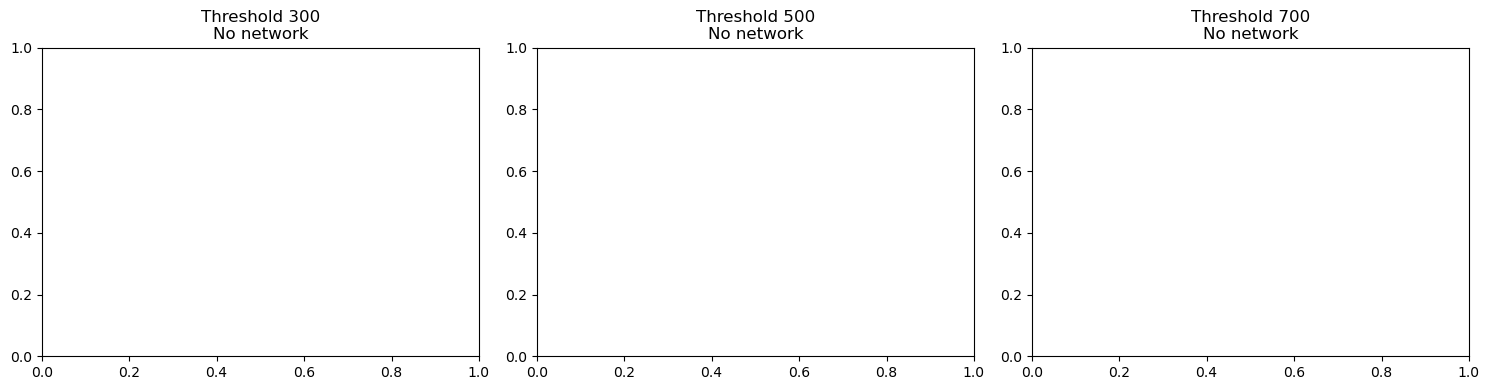

Threshold Comparison for IL10:
     nodes  edges
300      0      0
500      0      0
700      0      0


In [13]:
# Compare different thresholds for same protein
def compare_thresholds(protein_name, thresholds=[300, 500, 700]):
    """Compare networks with different score thresholds"""
    results = {}
    
    fig, axes = plt.subplots(1, len(thresholds), figsize=(5*len(thresholds), 4))
    if len(thresholds) == 1:
        axes = [axes]
    
    for i, threshold in enumerate(thresholds):
        analyzer = PathwayAnalyzer(score_threshold=threshold)
        network = analyzer.build_network(protein_name, max_levels=3, max_proteins_per_level=10)
        
        if network:
            stats, _, _ = analyzer.get_summary()
            results[threshold] = stats
            
            # Quick visualization
            plt.sca(axes[i])
            pos = nx.spring_layout(network, k=1)
            nx.draw(network, pos, node_size=50, alpha=0.7, node_color='lightblue')
            plt.title(f"Threshold {threshold}\n{stats['nodes']} nodes, {stats['edges']} edges")
        else:
            results[threshold] = {'nodes': 0, 'edges': 0}
            plt.sca(axes[i])
            plt.title(f"Threshold {threshold}\nNo network")
    
    plt.tight_layout()
    plt.show()
    
    # Summary table
    comparison_df = pd.DataFrame(results).T
    print(f"Threshold Comparison for {protein_name}:")
    print(comparison_df)
    
    return results

# Example comparison
compare_results = compare_thresholds("IL10", thresholds=[300, 500, 700])

# ## Step 6: Export Results

In [14]:
# Export network data
def export_network(analyzer, filename_prefix):
    """Export network to various formats"""
    if not analyzer.graph:
        print("No network to export")
        return
    
    # Export as GraphML (recommended for Cytoscape)
    graphml_file = f"{filename_prefix}.graphml"
    nx.write_graphml(analyzer.graph, graphml_file)
    print(f"✓ Exported to {graphml_file}")
    
    # Export edge list
    edge_file = f"{filename_prefix}_edges.csv"
    edges_data = []
    for u, v, data in analyzer.graph.edges(data=True):
        edges_data.append({
            'protein1': u,
            'protein2': v,
            'score': data['score'],
            'level': data['level']
        })
    
    edges_df = pd.DataFrame(edges_data)
    edges_df.to_csv(edge_file, index=False)
    print(f"✓ Exported edges to {edge_file}")
    
    # Export protein info
    protein_file = f"{filename_prefix}_proteins.csv"
    protein_data = []
    for name, info in analyzer.proteins.items():
        protein_data.append({
            'protein': name,
            'string_id': info.get('string_id', ''),
            'level': info.get('level', 0),
            'degree': analyzer.graph.degree(name) if analyzer.graph.has_node(name) else 0
        })
    
    proteins_df = pd.DataFrame(protein_data)
    proteins_df.to_csv(protein_file, index=False)
    print(f"✓ Exported proteins to {protein_file}")

# Export IL10 network
if 'analyzer' in locals() and analyzer.graph:
    export_network(analyzer, "IL10_network")

print("\n✓ High-Quality Pathway Analysis Complete!")
print("\nNew Features:")
print("  ✓ Evidence filtering: Only experimental AND database evidence")
print("  ✓ Configurable evidence score thresholds")
print("  ✓ Evidence quality visualization and statistics")
print("  ✓ Comparison tools for different filtering levels")
print("\nYou can now:")
print("  - Analyze any protein with high-quality evidence filtering")
print("  - Adjust evidence thresholds (100-1000) based on desired stringency")
print("  - Compare evidence filtering effects")
print("  - Export high-confidence networks for publication")
print("  - View evidence score distributions for quality assessment")
print("\nExample usage:")
print("  analyze_protein_high_quality('TP53', min_evidence_score=300)")
print("  compare_evidence_thresholds('BRCA1', thresholds=[200, 400, 600])")


✓ High-Quality Pathway Analysis Complete!

New Features:
  ✓ Evidence filtering: Only experimental AND database evidence
  ✓ Configurable evidence score thresholds
  ✓ Evidence quality visualization and statistics
  ✓ Comparison tools for different filtering levels

You can now:
  - Analyze any protein with high-quality evidence filtering
  - Adjust evidence thresholds (100-1000) based on desired stringency
  - Compare evidence filtering effects
  - Export high-confidence networks for publication
  - View evidence score distributions for quality assessment

Example usage:
  analyze_protein_high_quality('TP53', min_evidence_score=300)
  compare_evidence_thresholds('BRCA1', thresholds=[200, 400, 600])
